In [11]:
import sys
import os
my_path = os.path.dirname(os.getcwd())
sys.path.append(my_path)

# from prev_ob_models.Doxey2022.isolated_cells import *
import prev_ob_models.Doxey2022.isolated_cells as ic
from neuron import h
import matplotlib.pyplot as plt

In [12]:
if not os.path.isdir('../prev_ob_models/Doxey2022/Mechanisms/x86_64'):
    os.system('python ../prev_ob_models/Doxey2022/compile_mechs.py')
else:
    print('Mechanisms already compiled')
# ! python ../prev_ob_models/Doxey2022/compile_mechs.py

Mechanisms already compiled


## Load cells

In [22]:
# mc_cells = [ic.MC1(), ic.MC2(), ic.MC3(), ic.MC4(), ic.MC5()]
# tc_cells = [ic.TC1(), ic.TC2(), ic.TC3(), ic.TC4(), ic.TC5()]
gc_cells = [ic.GC1(), ic.GC2(), ic.GC3(), ic.GC4(), ic.GC5()]
# gc_cell = ic.GC3()

Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.
Mechanisms already loaded from path: Mechanisms.  Aborting.


## Initialize h

In [23]:
h.cvode_active(0)
delay = 200
dur = 700
h.tstop = 1000
h.celsius = 35
h.steps_per_ms = 10
h.dt = 1.0 / h.steps_per_ms

## Mitral Cells

In [15]:
mc_amps = [0.25, 0, -0.1]
# mc_amps = [0.2+(amp*0.01) for amp in list(range(0,10))]
# mc_amps = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

num_mc_cells = len(mc_cells)

In [16]:
mc_amps

[0.25, 0, -0.1]

Text(0, 0.5, 'membrane potential (mV)')

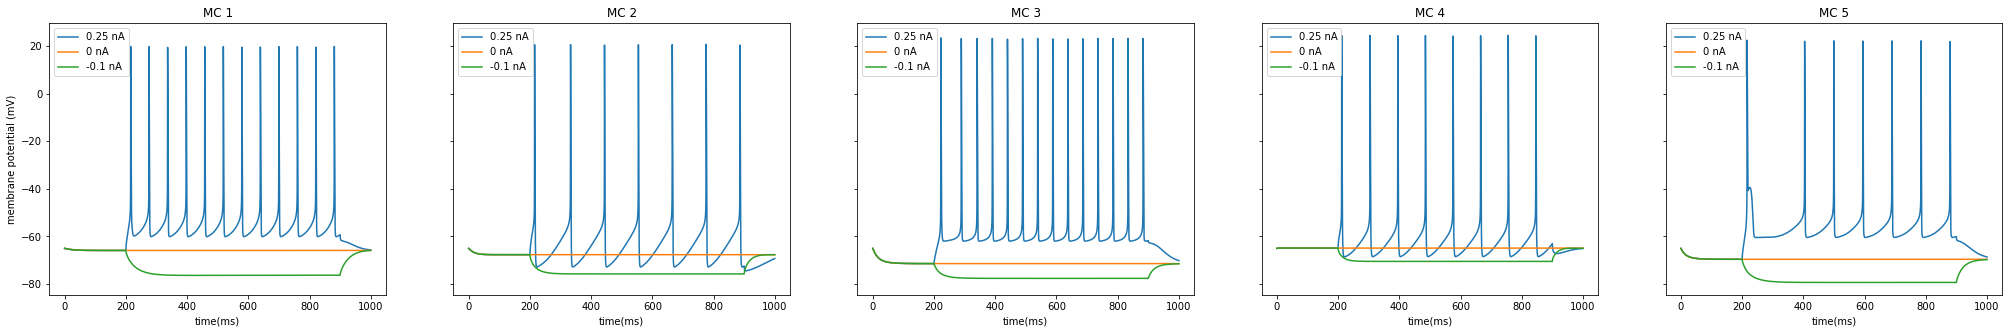

In [17]:
fig, axs = plt.subplots(1, num_mc_cells, figsize=(35,5), sharey=True)
axs = axs.ravel()

for idx, cell in enumerate(mc_cells):
    for amp in mc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)

        h.run()

        axs[idx].plot(t, v, label=f'{amp} nA')
    
    axs[idx].set_title(f'{cell.cell_type} {cell.cell_id}')

    axs[idx].legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs[idx].set_xlabel('time(ms)')

axs[0].set_ylabel('membrane potential (mV)')

## Tufted Cells

In [20]:
tc_amps = [0.25, 0, -0.1]

num_tc_cells = len(tc_cells)

Text(0, 0.5, 'membrane potential (mV)')

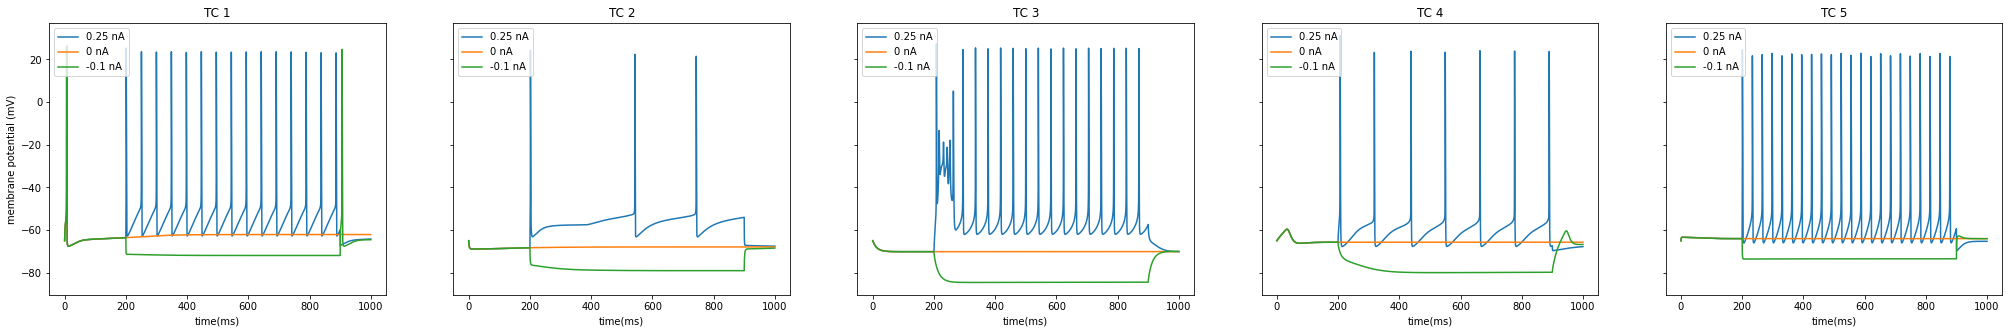

In [21]:
fig, axs = plt.subplots(1, num_tc_cells, figsize=(35,5), sharey=True)
axs = axs.ravel()

for idx, cell in enumerate(tc_cells):
    for amp in tc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)

        h.run()

        axs[idx].plot(t, v, label=f'{amp} nA')
    
    axs[idx].set_title(f'{cell.cell_type} {cell.cell_id}')

    axs[idx].legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs[idx].set_xlabel('time(ms)')

axs[0].set_ylabel('membrane potential (mV)')

## Granule Cells

In [24]:
gc_amps = [0.06, 0, -0.02]

num_gc_cells = len(gc_cells)

Text(0, 0.5, 'membrane potential (mV)')

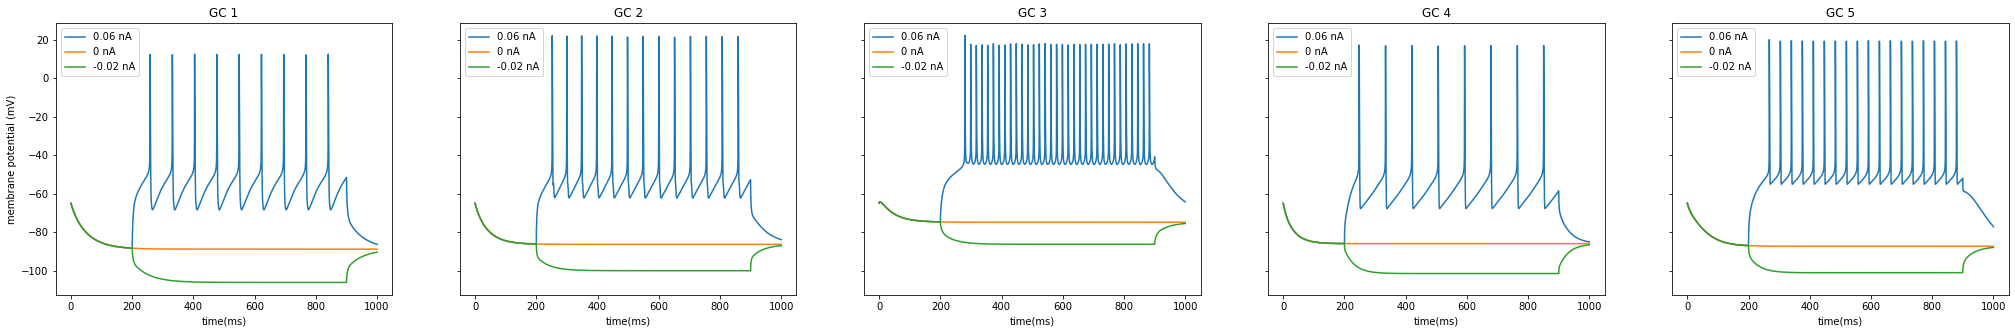

In [25]:
fig, axs = plt.subplots(1, num_gc_cells, figsize=(35,5), sharey=True)
axs = axs.ravel()

for idx, cell in enumerate(gc_cells):
    for amp in gc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)

        h.run()

        axs[idx].plot(t, v, label=f'{amp} nA')
    
    axs[idx].set_title(f'{cell.cell_type} {cell.cell_id}')

    axs[idx].legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs[idx].set_xlabel('time(ms)')

axs[0].set_ylabel('membrane potential (mV)')

In [ ]:
gc_amps = [0.06, 0, -0.02]
gc_cells = [gc_cell]
num_gc_cells = len(gc_cells)

Text(0, 0.5, 'membrane potential (mV)')

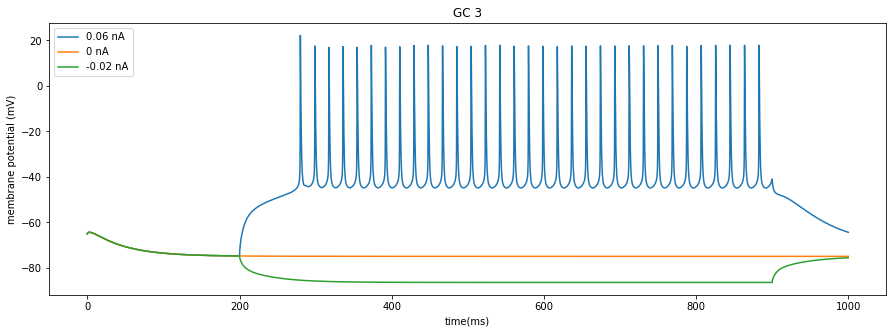

In [9]:
fig, axs = plt.subplots(1, num_gc_cells, figsize=(15,5), sharey=True)
# axs = axs.ravel()

for idx, cell in enumerate(gc_cells):
    for amp in gc_amps:
        iclamp = h.IClamp(0.5, sec=cell.soma)
        iclamp.delay = delay
        iclamp.amp = amp
        iclamp.dur = dur

        t = h.Vector().record(h._ref_t)
        v = h.Vector().record(cell.soma(0.5)._ref_v)

        h.run()

        axs.plot(t, v, label=f'{amp} nA')
    
    axs.set_title(f'{cell.cell_type} {cell.cell_id}')

    axs.legend(loc='upper left')
    # axs[idx].set_ylim((-110,30))
    axs.set_xlabel('time(ms)')

axs.set_ylabel('membrane potential (mV)')